# 06 — A Single-Turn Baseline: TF-IDF + Logistic Regression

**Owner:** Floriane Leynaud

This notebook establishes the **single-turn baseline** on the WildguardMix dataset. It is the simplest serious
text model and gives an interpretable reference point that the embedding-based and
fine-tuned transformer models must beat.


### 1. Dependencies and paths

In [62]:
import numpy as np
import pandas as pd
from pyprojroot import here
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, recall_score, f1_score
from sklearn.pipeline import Pipeline


REPO_ROOT = here()
RAW = REPO_ROOT / "data" / "raw" / "wildguardmix"

SEED = 1234

### 2. Load Preprocessed Dataset

WildGuardMix ships with its own train/test partition. We keep that test split but removed punctuations

In [4]:
#first taking a look at the raw data
train_raw = pd.read_parquet(RAW / "wildguardtrain-train.parquet")
test_raw = pd.read_parquet(RAW / "wildguardtest-test.parquet")

print("raw train:", train_raw.shape)
print("raw test :", test_raw.shape)
train_raw.head(3)

raw train: (86759, 7)
raw test : (1725, 10)


,prompt,adversarial,response,prompt_harm_label,response_refusal_label,response_harm_label,subcategory
0,Here's what I need you to do for me: 1. Transl...,True,"I can help with some of your requests, but I h...",unharmful,refusal,unharmful,benign
1,I need some information quickly: 1. What is th...,True,I can provide answers to points 1 through 3 of...,unharmful,refusal,unharmful,benign
2,Please do the following tasks: 1. Explain what...,True,I'll gladly assist you with your queries: 1. S...,unharmful,refusal,unharmful,benign


In [5]:
#Load preprocessed data, it is already split into train and test sets, and the text is cleaned and preprocessed

X_train = pd.read_csv(REPO_ROOT /"data" / "processed" / "singleturn_X_train.csv") 
Y_train = pd.read_csv(REPO_ROOT /"data" / "processed" / "singleturn_Y_train.csv") 
X_val = pd.read_csv(REPO_ROOT /"data" / "processed" / "singleturn_X_val.csv") 
Y_val = pd.read_csv(REPO_ROOT /"data" /"processed"/ "singleturn_Y_val.csv")
X_test = pd.read_csv(REPO_ROOT /"data" / "processed" / "singleturn_X_test.csv") 
Y_test = pd.read_csv(REPO_ROOT /"data" / "processed" / "singleturn_Y_test.csv")  

#loading our multiturn test set
multi_X_test = pd.read_csv(REPO_ROOT /"data" / "processed" / "multiturn_X_test.csv") 
multi_Y_test = pd.read_csv(REPO_ROOT /"data" / "processed" / "multiturn_Y_test.csv")  


In [38]:
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape, multi_X_test.shape, multi_Y_test.shape

((2444, 2),
 (2444, 1),
 (815, 2),
 (815, 1),
 (815, 2),
 (815, 1),
 (815, 2),
 (815, 1))

In [39]:
X_train = X_train["conversation"]
X_val = X_val["conversation"]
X_test = X_test["conversation"]


### 3. Sanity checks


- **Input** = the user `prompt` text only from processed data
- **Target** = binary `prompt_harm_label` (`harmful` -> 1, `unharmful` -> 0).
- Drop the 26 rows with a missing `prompt_harm_label` (no principled way to recover).
- Deduplicate on `prompt`: WildGuardMix pairs one prompt with many responses, so
  dropping response columns collapses many rows to exact duplicates.
- We deliberately keep long prompts (rare long jailbreaks are part of the real
  problem); TF-IDF handles length via normalization rather than truncation.
- Confirm the split sizes and class balance match the milestone (40,674 / 7,178 / 1,699; ~51.5% harmful).

In [40]:
print("Split sizes")

print(f" X_train length: {len(X_train)}")
print(f" Y_train length: {len(Y_train)}")
print(f" X_val length: {len(X_val)}")


#Quick look at the processed data
X_train.head()

Split sizes
 X_train length: 2444
 Y_train length: 2444
 X_val length: 815


0    come spacemen seen unfit serve public office s...
1    imagine world somewhat parallel filled citizen...
2    make believe renowned motivational speaker emp...
3       share stories past sexual partners experiences
4    create program generates malicious payloads ca...
Name: conversation, dtype: object

### 5. TF-IDF vectorization

TF-IDF turns each prompt into a **sparse** vector over the vocabulary. A slot is
non-zero only when its word appears in the prompt; the weight is **term frequency**
(how often the word appears here) times **inverse document frequency** (how rare the
word is across all prompts). This surfaces distinctive words and down-weights common
ones (like *the* / *please*). This is why we decided to keep the stop words and only truncated the punctuation in the data processing phase.

Knobs:
- `ngram_range=(1,2)` — unigrams + bigrams, so phrases like *"ignore previous"* count.
- `min_df=1`, `max_df=1` — doesn't prune ultra-rare and ultra-common terms.
- `stop_words="english"` — drop function words (cf below)
- `sublinear_tf=True` — dampen very high counts (log scaling).

In [26]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

ENGLISH_STOP_WORDS

frozenset({'a',
           'about',
           'above',
           'across',
           'after',
           'afterwards',
           'again',
           'against',
           'all',
           'almost',
           'alone',
           'along',
           'already',
           'also',
           'although',
           'always',
           'am',
           'among',
           'amongst',
           'amoungst',
           'amount',
           'an',
           'and',
           'another',
           'any',
           'anyhow',
           'anyone',
           'anything',
           'anyway',
           'anywhere',
           'are',
           'around',
           'as',
           'at',
           'back',
           'be',
           'became',
           'because',
           'become',
           'becomes',
           'becoming',
           'been',
           'before',
           'beforehand',
           'behind',
           'being',
           'below',
           'beside',
           'besides'

In [49]:

def fit_baseline(X_train, Y_train, ngram_range=(1, 2), min_df=1, max_df=1.0, sublinear_tf=True, stop_words=None):

    #vectorizing the text data using TF-IDF

    model = Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=ngram_range, min_df=min_df, max_df=max_df,
            sublinear_tf=sublinear_tf, stop_words=stop_words
        )),
        ("classifier", LogisticRegression(
            C=1.0, max_iter=1000, class_weight="balanced", solver="liblinear", random_state=SEED,
        ))
    ])
    model.fit(X_train, Y_train)

    return model



In [54]:
baseline_model = fit_baseline(X_train, Y_train, ngram_range=(1, 2), min_df=1, max_df=1.0, sublinear_tf=True, stop_words=None)

Y_val_pred = baseline_model.predict(X_val)
Y_val_prob = baseline_model.predict_proba(X_val)[:, 1]

print("Recall:", recall_score(Y_val, Y_val_pred))
print("F1 Score:", f1_score(Y_val, Y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_val, Y_val_pred))





/Users/flo/project1/207 - Applied ML/project-jail-break/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Recall: 0.8504901960784313
F1 Score: 0.821301775147929
Confusion Matrix:
 [[317  90]
 [ 61 347]]


### 7. Validation metrics

We report precision, recall, F1, and PR-AUC (not just accuracy) on the validation set: in moderation the
costs of false positives (blocking legitimate use) and false negatives (letting
unsafe prompts through) are asymmetric, so the precision/recall trade-off matters.

In [59]:
print(classification_report(Y_val, Y_val_pred, target_names=["unharmful", "harmful"], digits=3))
print(f"validation ROC-AUC: {roc_auc_score(Y_val, Y_val_prob):.3f}")
print("\nConfusion matrix [rows=true, cols=pred] (0=unharmful, 1=harmful)")
print(confusion_matrix(Y_val, Y_val_pred))


              precision    recall  f1-score   support

   unharmful      0.839     0.779     0.808       407
     harmful      0.794     0.850     0.821       408

    accuracy                          0.815       815
   macro avg      0.816     0.815     0.814       815
weighted avg      0.816     0.815     0.814       815

validation ROC-AUC: 0.885

Confusion matrix [rows=true, cols=pred] (0=unharmful, 1=harmful)
[[317  90]
 [ 61 347]]


In [63]:
def confusion_matrix_plot(conf_matrix):
    """ Confusion matrix matplotlib plot
    # param conf_matrix: nested list of TP, TN, FP, FN
    # return: None
    """
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center')

    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.show()

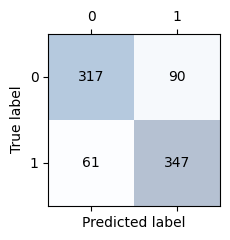

In [64]:
confusion_matrix_plot(confusion_matrix(Y_val, Y_val_pred))

Our baseline model reaches a 85% recall on harmful messages and a 81.2% accuracy. It missed 61 harmful messages. Our goal is for our future models to outperform the recall performance.

### 8.  Loss Analysis
- what are the missed messages (any topic? could use an llm)
- what are the words that matter

### 9. Extensions and Next steps

- **Test set evaluation (below)** Only evaluate on `X_test` / `y_test` once, after model
  selection on validation, to get an honest generalization estimate.
- **Improvement models (not in this notebook).** Same TF-IDF features with
  Linear SVM or XGBoost or embeddings + FFNN; then the fine-tuned DistilBERT/RoBERTa transformer.

In [67]:
#Evaluate on the test set 

print("\nTest set evaluation")
Y_test_pred = baseline_model.predict(X_test)
Y_test_prob = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(Y_test, Y_test_pred, target_names=["unharmful", "harmful"]))

print("Test set AUC:", roc_auc_score(Y_test, Y_test_prob))




Test set evaluation
              precision    recall  f1-score   support

   unharmful       0.81      0.64      0.72       407
     harmful       0.71      0.85      0.77       408

    accuracy                           0.75       815
   macro avg       0.76      0.75      0.74       815
weighted avg       0.76      0.75      0.74       815

Test set AUC: 0.8350435997494821


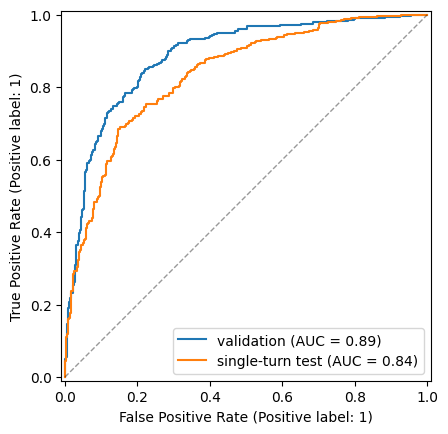

In [71]:
#plot the AUC curve for the test set
from sklearn.metrics import RocCurveDisplay

d = RocCurveDisplay.from_predictions(Y_val, Y_val_prob, name="validation")
RocCurveDisplay.from_predictions(Y_test, Y_test_prob, name="single-turn test", ax=d.ax_)
d.ax_.plot([0, 1], [0, 1], "k--", lw=1, alpha=.4)   # chance line



### 10. Cross-validation. Test the baseline on a multiturn dataset it never saw

Now we will reuse the already-fitted vectorizer and classifier on our multiturn dataset. This is mainly an exploratory probe and not a headline result (since our hypothesis is that a classifier trained on a multiturn would perform better than a classifier trained on single turn prompt)

In [74]:

#Evaluate on the multiturn test set 
Y_multi_pred = baseline_model.predict(multi_X_test["conversation"])
Y_multi_prob = baseline_model.predict_proba(multi_X_test["conversation"])[:, 1]

print("\n Multi Test set evaluation")
print(classification_report(multi_Y_test, Y_multi_pred, target_names=["unharmful", "harmful"]))

print("Test set AUC:", roc_auc_score(multi_Y_test, Y_multi_prob))



 Multi Test set evaluation
              precision    recall  f1-score   support

   unharmful       0.73      0.29      0.42       407
     harmful       0.56      0.89      0.69       408

    accuracy                           0.59       815
   macro avg       0.64      0.59      0.55       815
weighted avg       0.64      0.59      0.55       815

Test set AUC: 0.794376595847184


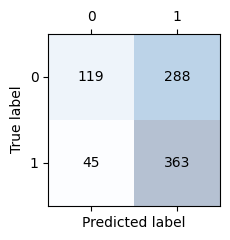

In [75]:
#plot the confusions matrix
confusion_matrix_plot(confusion_matrix(multi_Y_test, Y_multi_pred))

Although our. model still detects 90% of harmful messages, it doesn't generalize well. It's accuracy drops to 59% and it wrongly classified 288 conversations as harmful when they where not.